In [66]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    learning_curve,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
)

In [49]:
DATA_PATH = "../datasets/dermatology_database_1.csv"
TARGET = "class"
RANDOM_STATE = 13
TEST_SIZE = 0.2

In [50]:
data = pd.read_csv(DATA_PATH)

pd.set_option("display.max_columns", None)
print(data.shape)
display(data.head())
data.info()
data.isna().sum()

(366, 35)


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_infiltrate,PNL_infiltrate,fibrosis_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_rete_ridges,elongation_rete_ridges,thinning_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45,3


<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   erythema                             366 non-null    int64
 1   scaling                              366 non-null    int64
 2   definite_borders                     366 non-null    int64
 3   itching                              366 non-null    int64
 4   koebner_phenomenon                   366 non-null    int64
 5   polygonal_papules                    366 non-null    int64
 6   follicular_papules                   366 non-null    int64
 7   oral_mucosal_involvement             366 non-null    int64
 8   knee_and_elbow_involvement           366 non-null    int64
 9   scalp_involvement                    366 non-null    int64
 10  family_history                       366 non-null    int64
 11  melanin_incontinence                 366 non-null    int64
 12  eosin

erythema                               0
scaling                                0
definite_borders                       0
itching                                0
koebner_phenomenon                     0
polygonal_papules                      0
follicular_papules                     0
oral_mucosal_involvement               0
knee_and_elbow_involvement             0
scalp_involvement                      0
family_history                         0
melanin_incontinence                   0
eosinophils_infiltrate                 0
PNL_infiltrate                         0
fibrosis_papillary_dermis              0
exocytosis                             0
acanthosis                             0
hyperkeratosis                         0
parakeratosis                          0
clubbing_rete_ridges                   0
elongation_rete_ridges                 0
thinning_suprapapillary_epidermis      0
spongiform_pustule                     0
munro_microabcess                      0
focal_hypergranu

In [51]:
# find value that is string but not numeric and replace it with nan
data["age"] = pd.to_numeric(data["age"], errors="coerce")
data["age"] = data["age"].astype("Int64")

In [52]:
X = data.drop(columns=TARGET)
y = data[TARGET]

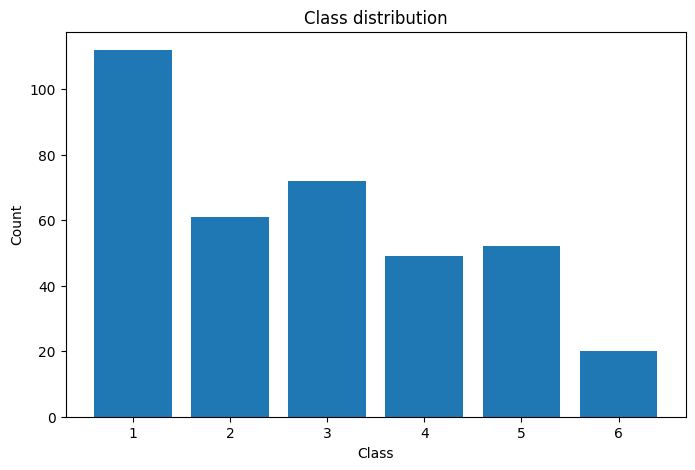

In [69]:
class_counts = y.value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Classes distributed unevenly, so best scoring metric for this dataset will be macro f1-score

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

In [ ]:
numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])

preprocessor = ColumnTransformer(
    [
        ("num", numeric_pipeline, X.columns),
    ]
)

In [74]:
model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]
)

In [75]:
# gridsearch, looking for combination of hyperparams with best metric

param_grid = {
    "clf__max_depth": [2, 3, 4, 5, 6, 8, None],
    "clf__min_samples_split": [2, 5, 10, 20],
    "clf__min_samples_leaf": [1, 2, 5, 10],
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__ccp_alpha": [0.0, 0.0001, 0.001],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True,
)

In [100]:
grid.fit(X_train, y_train)

model = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Best f1_macro score:", grid.best_score_)

Best params: {'clf__ccp_alpha': 0.0, 'clf__criterion': 'gini', 'clf__max_depth': 6, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Best f1_macro score: 0.9324776023695124


In [101]:
y_pred = model.predict(X_test)

In [102]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", accuracy)
print("f1_score macro:", f1)
print(classification_report(y_test, y_pred))

Accuracy: 0.9459459459459459
f1_score macro: 0.9337097934549209
              precision    recall  f1-score   support

           1       0.96      0.96      0.96        23
           2       0.86      1.00      0.92        12
           3       1.00      0.93      0.97        15
           4       0.90      0.90      0.90        10
           5       1.00      1.00      1.00        10
           6       1.00      0.75      0.86         4

    accuracy                           0.95        74
   macro avg       0.95      0.92      0.93        74
weighted avg       0.95      0.95      0.95        74



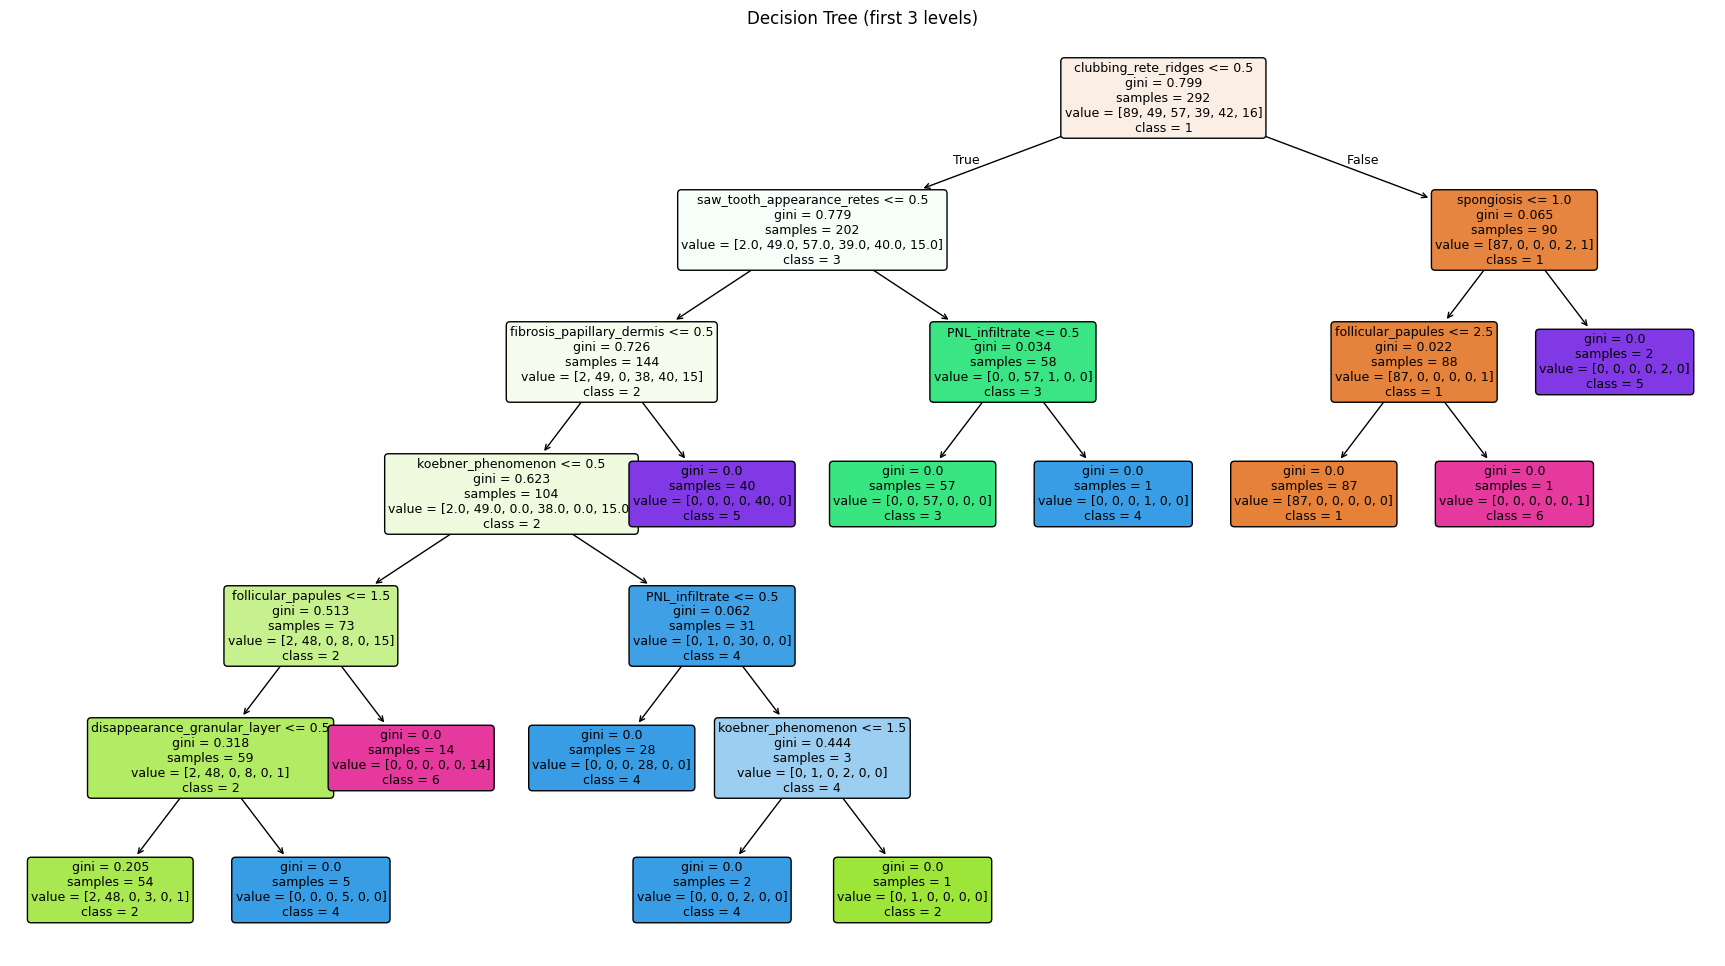

In [103]:
tree_model = model.named_steps["clf"]

plt.figure(figsize=(22, 12))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=[str(cls) for cls in tree_model.classes_],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Decision Tree (first 3 levels)")
plt.show()

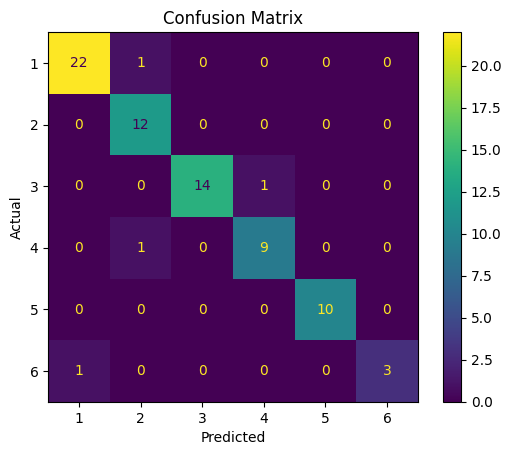

In [104]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

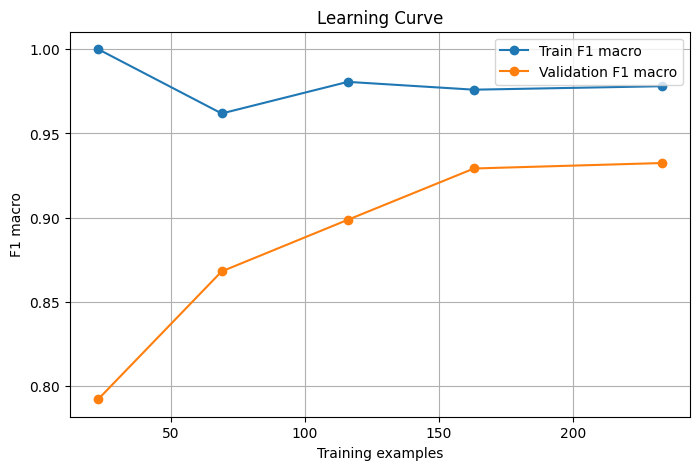

In [105]:
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="f1_macro",
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0],
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_STATE,
)

train_scores_mean = train_scores.mean(axis=1)
valid_scores_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, marker="o", label="Train F1 macro")
plt.plot(train_sizes, valid_scores_mean, marker="o", label="Validation F1 macro")
plt.title("Learning Curve")
plt.xlabel("Training examples")
plt.ylabel("F1 macro")
plt.legend()
plt.grid(True)
plt.show()